## 문제: 1차 상미분 방정식 풀기 (Forward Euler, RK4 방법 적용하여 비교)

위에서 Forward Euler 방법으로 풀었던 다음 1차 상미분 방정식(ODE)을 이번에는 RK4(Runge-Kutta 4th order) 방법을 사용하여 $t=0$ 부터 $t=10$ 까지의 시간 범위에서 $y(t)$ 값을 예측하는 코드를 PyTorch로 작성합니다.

$$\frac{dy}{dt} = -0.5y$$

초기 조건 $y(0) = 1$, 최종 시간 $t_{end} = 10$, 시간 간격 $\Delta t = 0.1$, 초기 조건 $y(0) = 1$, 상수 $k = 0.5$ 입니다.

**해석적 해:**
이 ODE의 해석적 해는 $y(t) = e^{-0.5t}$ 입니다. RK4 방법으로 얻은 결과와 비교해보세요.

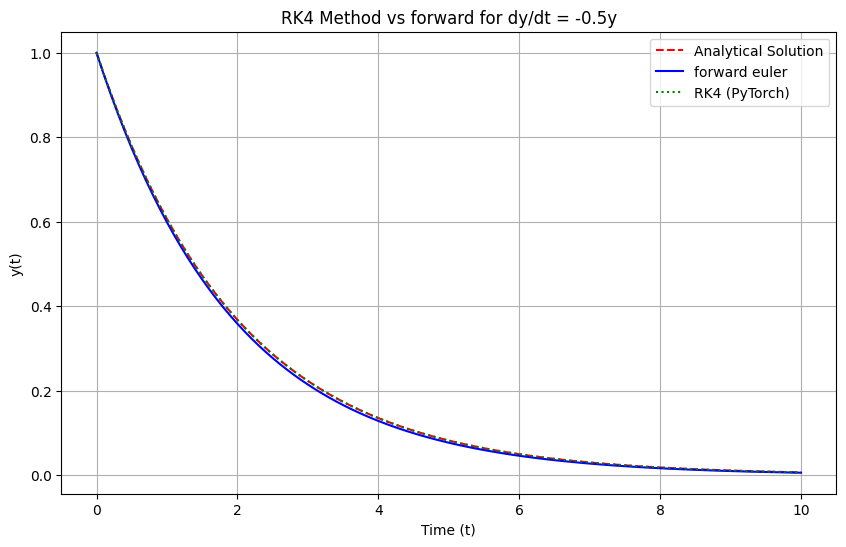

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. ODE 함수 정의: dy/dt = -k * y
def ode_function(t, y, k):
    return -k * y

# 2. 파라미터 설정
k = 0.5
y0 = torch.tensor(1.0)  # 초기 조건
t0 = 0.0
t_end = 10.0
dt = 0.1  # 시간 간격 (문제 명시된 값으로 설정)

# 시간 스텝 수 계산
num_steps = int((t_end - t0) / dt)

# 결과를 저장할 리스트 초기화
t_values = [t0]

y_rk4 = [y0.item()] #rk_4에 의한 추정 y
y_fw = [y0.item()]  #forward euler에 의한 추정 y

# RK4, forward 방법 구현
y_current_rk = y0
y_current_fw = y0
t_current = t0

for i in range(num_steps):
    # RK4 스텝 계산
    k1 = ode_function(t_current, y_current_rk, k)
    k2 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k1*dt, k)
    k3 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k2*dt, k)
    k4 = ode_function( t_current + dt, y_current_rk + k3*dt, k)

    # 다음 y_next_rk 값 업데이트
    y_next_rk = y_current_rk + dt*((k1 + 2*k2 + 2*k3 + k4) / 6)

    # 다음 y_next_fw 값 업데이트
    y_next_fw = y_current_fw + ode_function(t_current, y_current_fw, k)*dt


    # 시간 업데이트
    t_next = t_current + dt

    # 결과 저장
    t_values.append(t_next)
    y_rk4.append(y_next_rk.item())
    y_fw.append(y_next_fw.item())

    # 다음 스텝을 위해 값 업데이트
    y_current_rk = y_next_rk
    y_current_fw = y_next_fw
    t_current = t_next

# 3. 결과 시각화

# 해석적 해 계산
t_analytical = np.linspace(t0, t_end, 101)
y_analytical = np.exp(-k * t_analytical)

# plt.figure(figsize=(10, 6))
# plt.plot(t_analytical, y_analytical, label='Analytical Solution', color='red', linestyle='--')
# plt.plot(t_values, y_fw, label = 'forward euler', color = 'blue', linewidth = 1.5)
# plt.plot(t_values, y_rk4, label='RK4 (PyTorch)', color='green', linewidth = 1.5, linestyle=':')


# plt.title('RK4 Method vs forward for dy/dt = -0.5y')
# plt.xlabel('Time (t)')
# plt.ylabel('y(t)')
# plt.legend()
# plt.grid(True)
# plt.show()

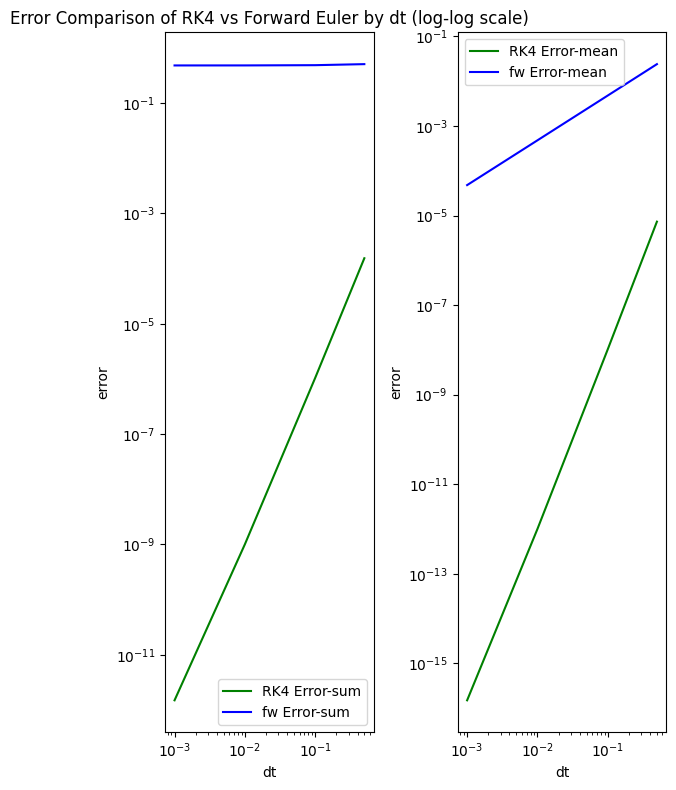

In [30]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. ODE 함수 정의: dy/dt = -k * y
def ode_function(t, y, k):
    return -k * y

dt_list = [0.5, 0.1, 0.01, 0.001] #시간 간격 여러개로

# 3. dt별 error 결과 저장 목적의 딕셔너리
sum_error_fw =[]
sum_error_rk =[]
mean_error_fw =[]
mean_error_rk =[]

# 2. 파라미터 설정
k = 0.5
y0 = torch.tensor(1.0, dtype=torch.float64) #초기 조건
t0 = 0.0
t_end = 10.0

for dt in dt_list:
  # 시간 스텝 수 계산
  num_steps = int((t_end - t0) / dt)

  # 결과 저장할 리스트 초기화
  t_values = [t0]
  y_rk4 = [y0.item()] #rk_4에 의한 추정y
  y_fw  = [y0.item()] #fw에 의한 추정y

  #사용할 변수 초기화
  y_current_rk = y0
  y_current_fw = y0
  t_current = t0

  for i in range(num_steps):
      #rk4 스텝 계산
      k1 = ode_function(t_current, y_current_rk, k)
      k2 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k1*dt, k)
      k3 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k2*dt, k)
      k4 = ode_function(t_current + dt, y_current_rk + k3*dt, k)

      # 다음 y_next_rk 값 업데이트
      y_next_rk = y_current_rk + dt*((k1 + 2*k2 + 2*k3 + k4) / 6)
      # 다음 y_next_fw 값 업데이트
      y_next_fw = y_current_fw + ode_function(t_current, y_current_fw, k)*dt
      # 시간 업데이트
      t_next = t_current + dt

      #결과 저장
      t_values.append(t_next)
      y_rk4.append(y_next_rk.item())
      y_fw.append(y_next_fw.item())
      #다음 스텝을 위해 값 업데이트
      y_current_rk = y_next_rk
      y_current_fw = y_next_fw
      t_current = t_next

  #답지 생성
  t_analytical = np.linspace(t0, t_end, num_steps+1)
  y_analytical = np.exp(-k * t_analytical)
  # if dt==0.5:
  #   print(type(y_analytical))

  error_rk4  = np.abs(np.array(y_rk4) - y_analytical).sum()
  error_fw   = np.abs(np.array(y_fw)  - y_analytical).sum()

  sum_error_rk.append(error_rk4)
  sum_error_fw.append(error_fw)

  merror_rk4  = np.abs(np.array(y_rk4) - y_analytical).mean()
  merror_fw   = np.abs(np.array(y_fw)  - y_analytical).mean()

  mean_error_rk.append(merror_rk4)
  mean_error_fw.append(merror_fw)

# 시각화
plt.figure(figsize= (6,8))

plt.subplot(1,2,1)
plt.loglog(dt_list, sum_error_rk, label='RK4 Error-sum', color='green', linewidth = 1.5)
plt.loglog(dt_list, sum_error_fw, label='fw Error-sum', color = 'blue', linewidth = 1.5)
plt.title('Error Comparison of RK4 vs Forward Euler by dt (log-log scale)')
plt.xlabel('dt')
plt.ylabel('error')
plt.legend()

plt.subplot(1,2,2)
plt.loglog(dt_list, mean_error_rk, label='RK4 Error-mean', color='green', linewidth = 1.5)
plt.loglog(dt_list, mean_error_fw, label='fw Error-mean', color = 'blue', linewidth = 1.5)
plt.xlabel('dt')
plt.ylabel('error')
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
sum_error_fw

[np.float64(0.5066022576175412),
 np.float64(0.4852385081606184),
 np.float64(0.48033317988635404),
 np.float64(0.4798408785106836)]